# Health Risk - Modeling
Integrantes:
- Diego Fabrizio Mucha Alvarez
- Ivan Ruben Cunyas Ramos
- Mauricio Andrés Canchis Fernández
- Juan Jose Rodriguez Velásquez
- María Laura Aragon Flores

En este notebook se realizará la fase 4 de CRISP-DM que es el modeling. Para esta fase vamos a probar 2 modelos de ML que nos permitan realizar la tarea para clasificar el riesgo de salud de los pacientes en ALDIMI.

In [1]:
# Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

## 1. Carga de la data

### 1.1. Cargar en un dataframe

In [2]:
df_processed = pd.read_csv("../data/processed/processed_data.csv")
df_processed = df_processed.sample(n=10000, random_state=42)

### 1.2. Separar en train y test

In [3]:
target_column = "survival_risk"

X = df_processed.drop(columns=[target_column])
y = df_processed[target_column]

### 1.3. Verificamos el tamaño de la data

In [4]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribución del target:")
print(y.value_counts())

Shape X: (10000, 49)
Shape y: (10000,)

Distribución del target:
survival_risk
0    2052
2    2047
3    1985
4    1962
1    1954
Name: count, dtype: int64


### 1.4. Train test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 49)
X_test: (2000, 49)
y_train: (8000,)
y_test: (2000,)


### 1.5. Escalamos la data

In [6]:
scaler = StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Modelo 1 - Regresión Logística

### 2.1. Creamos y entrenamos el modelo

In [7]:
logistic_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

logistic_model.fit(X_train, y_train)

/home/diegomucha/me/programming/projects/ALDIMI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### 2.2. Realizamos las predicciones

In [8]:
y_pred_logistic = logistic_model.predict(X_test)

### 2.3. Revisamos las metricas del modelo

In [9]:
print("Logistic Regression Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("F1 Macro:", f1_score(y_test, y_pred_logistic, average="macro"))
print("F1 Weighted:", f1_score(y_test, y_pred_logistic, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
----------------------------------------
Accuracy: 0.637
F1 Macro: 0.6277329471403503
F1 Weighted: 0.6279877755467848

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.68      0.67       411
           1       0.56      0.38      0.46       391
           2       0.61      0.56      0.59       409
           3       0.63      0.73      0.68       397
           4       0.68      0.83      0.75       392

    accuracy                           0.64      2000
   macro avg       0.63      0.64      0.63      2000
weighted avg       0.63      0.64      0.63      2000



### 2.4. Hacemos una matriz de confusión

In [ ]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 3. Modelo 2 - HistGradientBoostingClassifier

### 3.1. Creamos y entrenamos el modelo

In [10]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

### 3.2. Realizamos las predicciones

In [11]:
y_pred_hgb = hgb_model.predict(X_test)

### 3.3. Evaluamos las metricas

In [12]:
print("HistGradientBoostingClassifier Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("F1 Macro:", f1_score(y_test, y_pred_hgb, average="macro"))
print("F1 Weighted:", f1_score(y_test, y_pred_hgb, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))

HistGradientBoostingClassifier Results
----------------------------------------
Accuracy: 0.662
F1 Macro: 0.6534081936792688
F1 Weighted: 0.6533581569359733

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       411
           1       0.60      0.43      0.50       391
           2       0.63      0.60      0.61       409
           3       0.70      0.72      0.71       397
           4       0.69      0.91      0.78       392

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.65      2000
weighted avg       0.66      0.66      0.65      2000



### 3.4. Hacemos una matriz de confusión

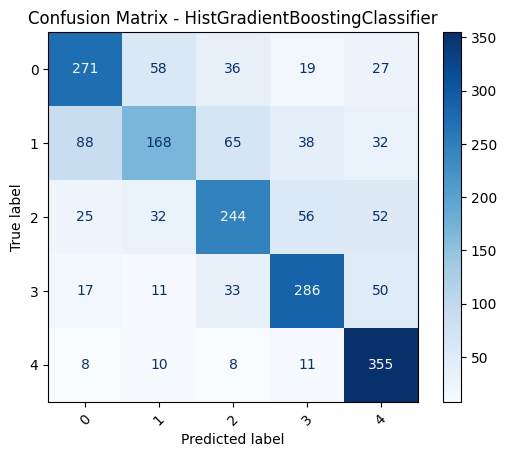

In [13]:
cm_hgb = confusion_matrix(y_test, y_pred_hgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_hgb)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - HistGradientBoostingClassifier")
plt.show()